# Construcción de los Números Naturales ($\mathbb{N}$)
---

Este conjunto de elementos se construye a partir de un elemento inicial (la semilla de inicialización), el cero $0$, y necesita un mecanismo de construcción: la función "sucesor", denotada como $S: \mathbb{N} \to \mathbb{N}^*$.

## Los Axiomas de Peano
¿De dónde viene la función sucseror $S: \mathbb{N} \to \mathbb{N}^*$? Esta función es, fundamentalmente, la expresión matemática que representa los **Axiomas de Peano**:

* **$A_1$**: El elemento $0$ es un natural ($0 \in \mathbb{N}$).
> Esto significa que inicialmente $\mathbb{N} \neq \emptyset$ (no está vacío) porque siempre contiene el cero. Es decir, $\mathbb{N} = \{0, \dots\}$.

* **$A_2$**: Todo $n \in \mathbb{N}$ tiene un único elemento sucesor $S(n)$ que también es natural ($S(n) \in \mathbb{N}$).
> Esto se traduce en que tenemos una aplicación (con propiedad de unicidad) que genera de forma iterativa todos los elementos de $\mathbb{N}$. Por tanto, tenemos $S: \mathbb{N} \to \mathbb{N}$.

* **$A_3$**: El $0$ no es sucesor de ningún natural.
> Es decir, la imagen de la aplicación sucesor $S$ no contiene al cero: $0 \notin \text{Im } S \Longrightarrow S: \mathbb{N} \to \mathbb{N}^*$ (siendo $\mathbb{N}^* = \mathbb{N} \setminus \{0\}$).

* **$A_4$**: Si dos naturales $n, n' \in \mathbb{N}$ tienen sucesores iguales ($S(n) = S(n')$), entonces $n = n'$ son iguales.
> Esto significa que dos elementos diferentes del dominio $\text{Dom } S$ siempre tienen imágenes diferentes. Es decir, no hay "más nidos que palomas", lo que define la **inyectividad** de la función. Por tanto, $S: \mathbb{N} \to \mathbb{N}^*$ es inyectiva.

* **$A_5$**: Si un conjunto $A$ contiene al cero ($0 \in A$) y a los sucesores de cero ($S(0) \in A, S(S(0)) \in A, \dots$), entonces contiene a todos los naturales ($\mathbb{N} \subseteq A$).
> Este axioma nos asegura que, usando solo el cero $0$ y la aplicación $S: \mathbb{N} \to \mathbb{N}^*$, podemos abarcar todo el conjunto de los naturales $\mathbb{N}$. Además, nos proporciona nuestra principal herramienta de demostración en $\mathbb{N}$: **El Principio de Inducción**.

## Visualización de los Naturales $\mathbb{N}$

Podemos visualizar el conjunto de los números naturales como la secuencia de aplicaciones sucesivas partiendo del cero:
$$\mathbb{N} = \{0, S(0), S(S(0)), S(S(S(0))), \dots \}$$

Donde la notación habitual simplemente simboliza estas iteraciones:
* $S(0) = 1$
* $S(S(0)) = 2$
* $S(S(S(0))) = 3$
* $\dots$

Los números $1, 2, 3$ representan simplemente el "sucesor de $0$", el "sucesor del sucesor de $0$", etc.

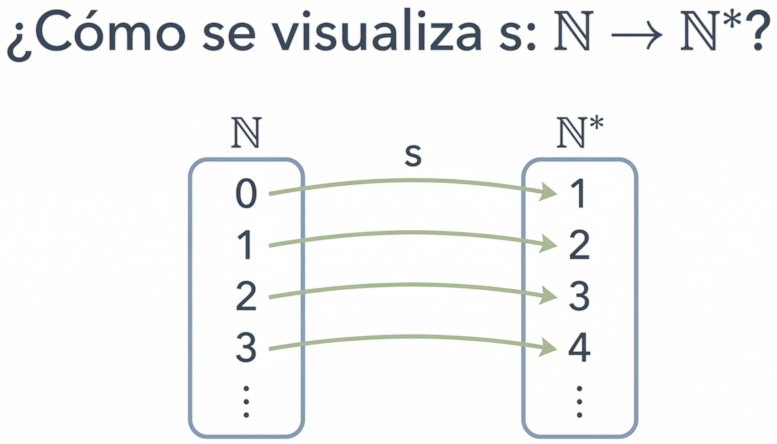

> **Nota del esquema:** Se ilustra una correspondencia (mapeo) de dos conjuntos visualizados como óvalos. El dominio $\mathbb{N}$ contiene $\{0, 1, 2, 3, \dots\}$ y el codominio $\mathbb{N}^*$ contiene $\{1, 2, 3, 4, \dots\}$. Flechas rectas conectan cada $n$ con su $n+1$ ($0 \to 1$, $1 \to 2$, etc.). Esto ilustra que $\mathbb{N}$ es un conjunto donde todos los elementos tienen un ancestro común ($0$), formando un linaje donde $S(n)$ significa "el hijo o sucesor de $n$"; como una familia de hijos únicos.

In [ ]:
# ∀x,x′∈A|f(x)=f(x′)⇒x=x′ propiedad inyetiva
is_injective(𝘧::Function, dom::Set) = all([
    !( 𝘧(x)==𝘧(x′) ) || (x == x′) # f(x)=f(x′) ⇒ x=x′
    for x ∈ dom for x′ ∈ dom
    ])

is_injective (generic function with 1 method)

In [ ]:
# A1:
ℕ =Set(0)

# Aplicacion sucesor:
function S(n)
    # A2:
    sucesor = n + 1
    # A3:
    if n < 0
        error("El  0  no es sucesor de ningún natural")
    end
    return sucesor
end

# Generamos los naturales hasta el 10
while length(ℕ) ≤ 10
    last_element = sort(collect(ℕ))[end]
    push!(ℕ, S(last_element))
end

display(ℕ)
# A4:
println(":: ¿Es 𝘧 inyectiva?: $(is_injective(S, ℕ))")

Set{Int64} with 11 elements:
  5
  8
  1
  0
  6
  9
  3
  7
  4
  2
  10

:: ¿Es 𝘧 inyectiva?: true


# La Suma en $\mathbb{N}$
---

Normalmente, definimos la suma $+$ como una aplicación binaria para la estructura $(\mathbb{N}, +)$:
$$+: \mathbb{N} \times \mathbb{N} \to \mathbb{N}$$
Sin embargo, esto solo nos dice que entran dos elementos y sale uno (es decir, $+(a, b) = c$), pero no nos da información del proceso interno; actúa como una "caja negra".

### La Suma como mecanismo recursivo (Recurrencia)

Recordemos que, en este punto fundacional, solo tenemos un elemento semilla ($0$) y una aplicación sucesor ($S: \mathbb{N} \to \mathbb{N}^*$). Usando **exclusivamente** estos dos elementos, definimos el mecanismo de la suma matemática mediante dos pasos recursivos:

$\forall m, x \in \mathbb{N}$, la operación $m + x$ se define como:
1.  **Caso base:** Si $x = 0 \implies m + 0 = m$
    > Esto se alinea con el hecho de que $0$ es considerado el elemento neutro en $(\mathbb{N}, +)$.
2.  **Paso recursivo:** Si $x = S(n) \implies m + S(n) = S(m + n)$
    > Esto aplica para todo elemento de $\mathbb{N}$ excepto el cero, ya que todo elemento no nulo es sucesor de algún otro.

**¿Por qué es recursiva?**
Porque evaluar $m + S(n)$ significa aplicar la aplicación sucesor $S$ múltiples veces (específicamente $S(n)$ veces) sobre $m$. Es decir, significa encontrar el sucesor de $m$ muchas generaciones en el futuro.

**Ejemplo de desarrollo recursivo ($m=5, n=2$):**
$$m + S(n) = 5 + S(2) = 8$$
Si desglosamos el proceso recursivo:
$$S(5 + 2) = 8$$
$$S(5 + S(1)) = 8$$
$$S(S(5 + 1)) = 8$$
$$S(S(5 + S(0))) = 8$$
$$S(S(S(5 + 0))) = 8 \implies S(S(S(5))) = 8$$
En este caso, $8$ es el tercer sucesor de $5$, lo que a su vez significa que es el octavo sucesor de $0$ ($5$ es $S(S(S(S(S(0)))))$).

## Consecuencias de la Suma Recursiva y Demostraciones

Una de las consecuencias más útiles de que la suma sea recursiva es que se cumple la siguiente equivalencia, que servirá como bloque de construcción para futuras demostraciones:

$$m + 1 = S(m)$$

**Demostración (por la propia recursividad):**
$$m + 1 = m + S(0) = S(m + 0) = S(m)$$
Esto es fundamental porque nos permite pasar de la notación conjuntista de aplicaciones ($S(m)$) a la notación algebraica clásica ($m+1$), que resulta mucho más práctica.

**Otras consecuencias notables:**
1.  $\forall m, n \in \mathbb{N}, \quad m + n = 0 \implies m = n = 0$
    > La única forma de que el resultado de sumar dos elementos naturales sea $0$ es que ambos operandos sean cero.
2.  Así como $m + 1 = S(m)$, también se cumple que **$1 + m = S(m)$**. Esto se demuestra mediante inducción.

### Herramienta: Demostración por Inducción (Ejemplo: $1 + m = S(m)$)

La demostración por inducción matemática se ejecuta sistemáticamente en tres pasos:

* **Paso 1: Verificar el caso semilla ($m=0$).**
    $$1 + 0 = S(0)$$
    $$ 1 = S(0) \quad \text{(Verdadero)}$$
* **Paso 2: Asumir que se cumple para $n$ (Hipótesis Inductiva).**
    Si $m = n$, asumimos como cierto que:
    $$1 + n = S(n)$$
    Este paso define la herramienta que usaremos para resolver el paso final.
* **Paso 3: Verificar que se cumple para el siguiente elemento ($n+1$).**
    Si $m = n + 1$, entonces sustituyendo:
    $$1 + (n + 1) = S(n + 1)$$
    Sabiendo que $n+1 = S(n)$ (por notación), desarrollamos el lado izquierdo:
    $$1 + (n + S(0)) = S(n + 1)$$
    $$1 + S(n + 0) = S(n + 1)$$
    $$1 + S(n) = S(n + 1)$$
    Ahora aplicamos la hipótesis inductiva del Paso 2 (donde asumimos que $1+n = S(n)$):
    $$S(1 + n) = S(n + 1)$$
    $$S(S(n)) = S(n + 1)$$
    Como $S(1+n) = S(S(n)) = S(n+1)$, por tanto demostramos que $1+n = S(n) = n+1$.


## Propiedades de la Suma ($+$) en $\mathbb{N}$

No olvidemos que la suma $+$ es una operación interna de la estructura algebraica $(\mathbb{N}, +)$. Cumple las siguientes propiedades:

1.  **Elemento Neutro:** Tiene un neutro $e_+ = 0$. Es decir, $m + 0 = m$ (consecuente con la definición recursiva).
2.  **Asociativa:** $m + (n + p) = (m + n) + p$
3.  **Conmutativa:** $m + n = n + m$
4.  **Cancelativa:** Si $m + p = n + p \implies m = n$

**Reflexión sobre la Propiedad Cancelativa:**
¿Por qué los números naturales son cancelativos si en este conjunto no tenemos elementos simétricos u opuestos (como los números negativos)?
Esta propiedad no depende de la existencia de inversos, sino de la **naturaleza inyectiva** de la aplicación sucesor $S$.

**Demostración de la propiedad cancelativa por Inducción (sobre $p$):**
* **Paso 1 ($p=0$):**
    $$m + 0 = n + 0 \implies m = n$$
* **Paso 2 (Hipótesis para $p$):**
    Supongamos cierto que $m + p = n + p \implies m = n$.
* **Paso 3 (Demostrar para $p+1$, que es $S(p)$):**
    Partimos de la igualdad en el siguiente sucesor:
    $$m + S(p) = n + S(p)$$
    Por la definición recursiva de la suma:
    $$S(m + p) = S(n + p)$$
    Aquí interviene la clave: Si $m+p$ y $n+p$ tienen la misma imagen, entonces, como **$S$ es inyectiva**, sus preimágenes deben ser iguales. Por lo tanto:
    $$m + p = n + p$$
    Y aplicando la hipótesis del Paso 2, concluimos que:
    $$m = n$$

In [ ]:
# Recursividad de la suma
function ∔(m::Int, S_n::Int)
    # Caso base: Si  x=0 ⟹ m+0=m
    if S_n == 0
        return m
    # Paso recursivo: Si  x=S(n) ⟹ m+S(n)=S(m+n)
    else
        # m+S(n) = S(m+n) = S(S(S(...S(m)...)))
        for _ in 1:S_n # numero de veces aplicando S()
            m = S(m)
        end
        return m
    end
end

∔ (generic function with 1 method)

In [ ]:
# Caso base: Si  x=0 ⟹ m+0=m
@show 1 ∔ 0
# Paso recursivo: Si  x=S(n) ⟹ m+S(n)=S(m+n)
@show 1 ∔ 4
@show 10 ∔ 4;

1 ∔ 0 = 1
1 ∔ 4 = 5
10 ∔ 4 = 14


# El Producto en $\mathbb{N}$

El producto matemático hereda directamente la naturaleza recurrente de la suma. Existe una clara cadena de dependencias formales:
El producto ($\cdot$) depende de la suma ($+$) $\longrightarrow$ que depende de la función sucesor $S(n)$ $\longrightarrow$ que depende de los Axiomas de Peano.

### Definición Recursiva del Producto

Para cualquier par de elementos $m, n \in \mathbb{N}$:
1.  **Caso Base:** $m \cdot 0 = 0$
    > El neutro aditivo ($0$) actúa como un elemento absorbente en la estructura $(\mathbb{N}, \cdot)$.
2.  **Paso Recursivo:** $m \cdot S(n) = m \cdot n + m$
    > Como la suma es recurrente y el producto está definido en base a la suma, el producto también es estrictamente recurrente.

**¿Cómo visualizar la naturaleza recurrente del producto?**
Ejemplo para $m=5, n=2$:
Evaluamos $m \cdot S(n) = 5 \cdot S(2)$. Sabemos que $S(2)$ es $3$, así que buscamos $5 \cdot 3$:
$$5 \cdot S(2) = 5 \cdot 2 + 5$$
Desglosando el término $5 \cdot 2$ (que es $5 \cdot S(1)$):
$$(5 \cdot S(1)) + 5 = (5 \cdot 1 + 5) + 5$$
Desglosando el término $5 \cdot 1$ (que es $5 \cdot S(0)$):
$$((5 \cdot S(0)) + 5) + 5 = ((5 \cdot 0 + 5) + 5) + 5$$
Aplicando el caso base ($5 \cdot 0 = 0$):
$$((0 + 5) + 5) + 5 = 5 + 5 + 5 = 15$$

**Consecuencias Inmediatas:**
1.  $m \cdot S(n) = m \cdot (n + 1)$, ya que $S(n) = n + 1$.
2.  Dado que $m \cdot S(0) = m \cdot 0 + m = 0 + m = m$, y sabiendo que $S(0) = 1$, obtenemos:
$$m \cdot 1 = m$$
Esto define la existencia del **neutro multiplicativo** ($1$) en la estructura $(\mathbb{N}, +, \cdot)$.

## Propiedades del Producto

De manera similar a la suma, el producto tiene las siguientes propiedades para todo $m, n, p \in \mathbb{N}$:

1.  **Elemento Neutro:** $e_\cdot = 1 \implies m \cdot 1 = 1 \cdot m = m$
2.  **Distributiva respecto a la suma:** $m \cdot (n + p) = m \cdot n + m \cdot p$
3.  **Asociativa:** $(m \cdot n) \cdot p = m \cdot (n \cdot p)$
4.  **Conmutativa:** $m \cdot n = n \cdot m$
5.  **Cancelativa:** $m \cdot p = n \cdot p \quad \text{con } p \neq 0 \implies m = n$

**Nota sobre el elemento absorbente:**
Debido a las propiedades conmutativa y cancelativa, hay una consecuencia importante:
$$\forall m, p \in \mathbb{N}, \quad m \cdot p = 0 \implies m = 0 \lor p = 0$$
Es decir, si el resultado es $0$ (el neutro aditivo absorvente), esto solo puede ocurrir si al menos uno de los operandos es cero, o quizás ambos.

### Demostración de la Propiedad Cancelativa del Producto
Al igual que en la suma, aunque no tenemos simétricos (inversos multiplicativos), la inyectividad de $S: \mathbb{N} \to \mathbb{N}$ nos permite efectuar la cancelación. Lo demostramos por inducción:

Queremos probar que si $m \cdot p = n \cdot p$ (con $p \neq 0$), entonces $m = n$.
* **Paso 1 ($n=0, p \neq 0$):**
    $$m \cdot p = 0 \cdot p \implies m \cdot p = 0$$
    Pero como $p \neq 0$, $p$ debe ser sucesor de algún elemento $q$ ($p = S(q)$).
    $$m \cdot S(q) = 0 \implies m \cdot q + m = 0$$
    Por consecuencia de las propiedades de la suma vistas anteriormente (la única forma de sumar cero en $\mathbb{N}$ es $0+0$), se deduce que:
    $$m \cdot q = 0 \quad \text{y} \quad m = 0$$
    Como $n=0$ y $m=0$, entonces $m=n$.
* **Paso 2 (Hipótesis Inductiva):**
    Suponemos cierto que para un $n$ genérico (y $p \neq 0$):
    $$m \cdot p = n \cdot p \implies m = n$$
* **Paso 3 (Demostrar para el sucesor $S(n)$):**
    Asumimos la igualdad de los productos para el sucesor:
    $$m \cdot p = S(n) \cdot p$$
    Dado que $m \cdot p$ es múltiplo de $p$ y asumiendo $m > 0$, $m$ también es sucesor de algún elemento $r$, es decir, $m = S(r)$. Sustituimos:
    $$S(r) \cdot p = S(n) \cdot p$$
    Pasando a notación algebraica ($S(x) = x+1$):
    $$(r + 1) \cdot p = (n + 1) \cdot p$$
    Aplicando la propiedad distributiva:
    $$r \cdot p + p = n \cdot p + p$$
    Por la inyectividad de la suma (propiedad cancelativa de la suma):
    $$r \cdot p = n \cdot p$$
    Por lo asumido en el Paso 2 (nuestra hipótesis inductiva para el producto):
    $$r = n$$
    Finalmente, aplicando la inyectividad de la función sucesor $S$ (si dos elementos son iguales, tienen la misma imagen):
    $$S(r) = S(n) \implies m = S(n)$$
    Lo que preserva la estructura de la relación buscada.


In [ ]:
# Recursividad del prducto
function ∙(m::Int, S_n::Int)
    # Caso Base:  m⋅0=0
    if S_n == 0
        return 0
    # Paso Recursivo:  m⋅S(n)=m⋅n+m
    else
        # m⋅S(n)=m⋅n+m = m+m+...+m
        n = S_n - 1
        inicial = m
        # Note: se necesitan dos loops
        # ----------------------------
        for _ in 1:n # numero de sumas
            for _ in 1:m # numero de veces aplicando S()
                inicial = S(inicial)
            end
        end
        return inicial
    end
end

∙ (generic function with 1 method)

In [ ]:
# Caso base: Si  x=0 ⟹ m+0=m
@show 1 ∙ 0
@show 1 ∙ 1
# Paso recursivo: Si  x=S(n) ⟹ m+S(n)=S(m+n)
@show 1 ∙ 4
@show 10 ∙ 4;

1 ∙ 0 = 0
1 ∙ 1 = 1
1 ∙ 4 = 4
10 ∙ 4 = 40


# La Potenciación en $\mathbb{N}$

La potenciación hereda nuevamente la naturaleza recursiva del producto, ya que está definida en base al producto, que a su vez estaba definido por la suma.

La potencia $n$-ésima de un número $a$ se expresa clásicamente como multiplicar la base $a$ por sí misma $n$ veces:
$$a^n = \underbrace{a \cdot a \cdot a \cdot \dots \cdot a}_{n \text{ veces}}$$

### Definición Recursiva de la Potenciación
$\forall a \in \mathbb{N}^*, \forall n \in \mathbb{N}$:

1.  **$a^0 = 1$** (Usa el neutro multiplicativo)
2.  **$0^n = 0$** (Usa el neutro aditivo como absorbente)
3.  **$a^{S(n)} = a^{n+1} = a^n \cdot a$** (Definición construida mediante el producto recurrente)

**Ejemplo de desarrollo recursivo ($a=5, n=2$):**
$$5^{S(2)} = 5^{2+1} = 5^2 \cdot 5$$
Aplicando recurrencia al $5^2$:
$$= (5^{S(1)}) \cdot 5 = (5^1 \cdot 5) \cdot 5$$
Aplicando recurrencia al $5^1$:
$$= (5^{S(0)} \cdot 5) \cdot 5 = (5^0 \cdot 5) \cdot 5 \cdot 5$$
Aplicando el caso base ($5^0 = 1$):
$$= 1 \cdot 5 \cdot 5 \cdot 5 = 5 \cdot 5 \cdot 5$$
Por tanto, $5^{S(2)} = 5^3 = 5 \cdot 5 \cdot 5$.

## Consecuencias y Propiedades de la Potenciación

Para todo $\forall (a, m, n) \in \mathbb{N}^* \times \mathbb{N} \times \mathbb{N}$:

1.  **Producto de potencias con misma base:**
    Debido a la definición recursiva ($a^{n+1} = a^n \cdot a$), es evidente que:
    $$a^m \cdot a^n = a^{m+n}$$

2.  **Potencia de una potencia:**
    $$(a^n)^m = a^{n \cdot m}$$
    *Demostración por Inducción (sobre $m$):*
    * **Paso 1 ($m=0$):** $(a^n)^0 = a^{n \cdot 0} \implies 1 = a^0 \implies 1 = 1$
    * **Paso 2 (Hipótesis):** Asumimos $(a^n)^m = a^{n \cdot m}$
    * **Paso 3 ($m = S(m)$):** Evaluamos para el sucesor $m+1$:
$$(a^n)^{S(m)} = a^{n \cdot S(m)}$$
$$(a^n)^{m+1} = a^{n \cdot S(m)}$$
Desarrollando el lado izquierdo con la definición de potencia:
$$(a^n)^m \cdot a^n = a^{n \cdot S(m)}$$
Aplicando la Hipótesis del Paso 2:
$$a^{n \cdot m} \cdot a^n = a^{n \cdot S(m)}$$
Sumando exponentes (Propiedad 1):
$$a^{n \cdot m + n} = a^{n \cdot S(m)}$$
Sacando factor común $n$:
$$a^{n \cdot (m+1)} = a^{n \cdot S(m)} \implies a^{n \cdot S(m)} = a^{\cdot S(m)}$$
Quedando así demostrado.

3.  **Potencia de un producto:**
    $$a^n \cdot b^n = (a \cdot b)^n$$
    *Se demuestra por inducción. Verificando el primer caso semilla (Paso 1 con $n=0$):*
    $$a^0 \cdot b^0 = (a \cdot b)^0$$
    $$1 \cdot 1 = 1 \implies 1 = 1$$

In [ ]:
# Recursividad de la potenciacion
function ∧(a::Int, S_n::Int)
    # Caso: a^0=1  (Usa el neutro multiplicativo)
    if S_n == 0
        return 1
    # Caso: 0^n=0  (Usa el neutro aditivo como absorbente)
    elseif a == 0
        return 0
    # Paso Recursivo:  a^S(n)= a^n+1 = a^n ⋅ a
    else
        # a^S(n) = a^n ⋅ a = a ⋅ a ⋅ a ... ⋅ a
        n = S_n-1
        last_sucesor = a
        # Note: se necesitan tres loops
        # -----------------------------
        for _ in 1:n # numero de multiplicaciones
            n_sucesores = last_sucesor
            # Paso Recursivo multiplicacion:  a⋅a = a⋅(a-1)+a = a+a+...+a
            for _ in 1:a-1 # numero de sumas
                for _ in 1:n_sucesores # numero de veces aplicando S() ¡mutable e incremental!
                    last_sucesor = S(last_sucesor)
                end
            end
        end
        return last_sucesor
    end
end

∧ (generic function with 1 method)

In [ ]:
# Caso base: a^0=1  (Usa el neutro multiplicativo)
@show 1 ∧ 0
# Caso base: 0^n=0  (Usa el neutro aditivo como absorbente)
@show 0 ∧ 1
# Paso recursivo: a^S(n) = a^n ⋅ a = a ⋅ a ⋅ a ... ⋅ a
@show 1 ∧ 4
@show 2 ∧ 2;
@show 2 ∧ 3;
@show 2 ∧ 8;
@show 3 ∧ 2;
@show 3 ∧ 3;

1 ∧ 0 = 1
0 ∧ 1 = 0
1 ∧ 4 = 1
2 ∧ 2 = 4
2 ∧ 3 = 8
2 ∧ 8 = 256
3 ∧ 2 = 9
3 ∧ 3 = 27


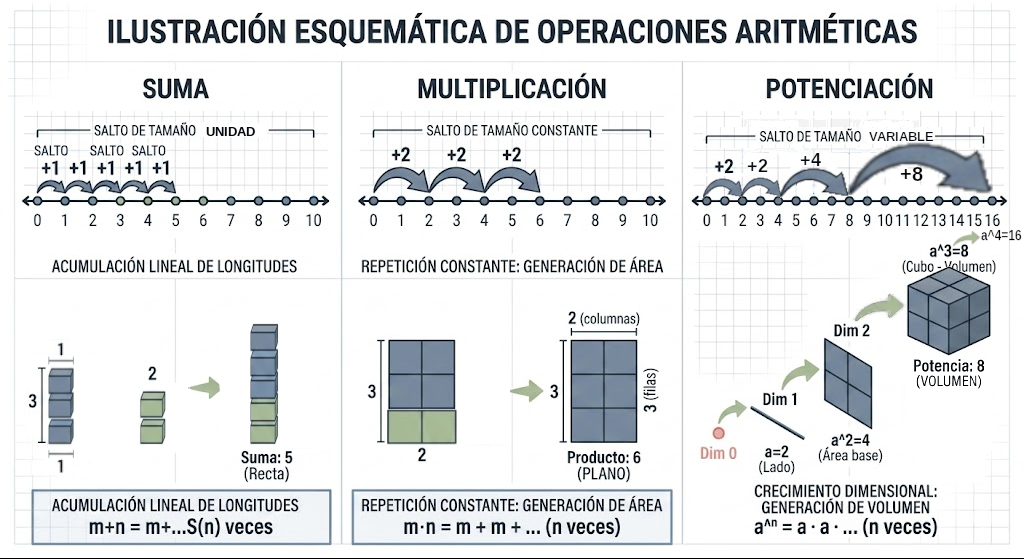

> **Intuición:** La expresión $a^n$ es la fórmula matemática del empaquetado jerárquico o la ramificación fractal o anidación: la base $a$ te dicta la cantidad de elementos o ramificaciones que hay en cada nivel (cuántas subcarpetas hay dentro de una carpeta, cuántas venas salen de una arteria, o cuántas opciones se abren en una decisión), mientras que el exponente $n$ te indica la profundidad del sistema (cuántos niveles de carpetas y subcarpetas abres, o cuántas ramificaciones ocurren *e.g.* de las $a$ arterias salen $a$ arteriolas y de las $a$ arteriolas salen $a$ capilares asi hasta llegar al nivel $n$ de ramificación); por lo tanto, calcular $a^n$ es simplemente contar la cantidad total de archivos, capilares o realidades posibles que existen al fondo de toda esa jerarquía anidada.

# Ordenación de los Números Naturales: $(\mathbb{N}, \le)$

La relación de orden $\le$ está intrínsecamente definida a través de la operación de la suma $+$. Como la suma es una operación recurrente, la relación $\le$ también hereda esta naturaleza recursiva al aplicar los Axiomas de Peano, utilizando la función sucesor $S: \mathbb{N} \to \mathbb{N}$.

Conceptualmente, la relación de orden en $(\mathbb{N}, \le)$ representa **cuántas veces tengo que aplicar $S(m)$ para llegar a $n$**. En otras palabras, nos dice cuántos sucesores ("generaciones") existen entre dos elementos $m, n \in \mathbb{N}$.

## Definición Formal

Para cualesquiera $m, n \in \mathbb{N}$:

$$m \le n \implies \exists p \in \mathbb{N}, \; m + p = n$$

* **Interpretación:** Esto significa que existen $p$ generaciones (sucesores) entre $m$ y $n$. La relación inversa $\ge$ utiliza la misma lógica pero en sentido opuesto.
* **Mecanismo recursivo:** Debo aplicar recursivamente $S(m)$ unas $p$ veces para llegar a $n$. Es decir:
$$\underbrace{S(S(S(\dots (m) \dots)))}_{p \text{ veces}} = n$$
En otras palabras, $n$ es el sucesor número $p$ de $m$.
* **La pregunta fundamental:** La expresión $m \le n$ responde a la pregunta: *¿Es $m$ ancestro de $n$, o es $n$ mismo?*

### Visualización en la Recta Numérica

Podemos visualizar esto en una recta numérica donde a la izquierda tenemos el elemento $0$ (el predecesor o ancestro común de todos los elementos) y hacia la derecha se despliegan todos sus sucesores.


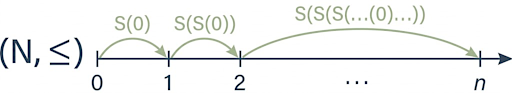

> **Descripción del esquema:** Una línea horizontal que comienza en $0$ y avanza hacia $1, 2, \dots, n$. Arcos por encima de la línea muestran los saltos: de $0$ a $1$ es $S(0)$, de $1$ a $2$ es $S(S(0))$, etc., hasta llegar a $n$ mediante múltiples aplicaciones de $S$.
> **Nota visual:** Entre más nos movamos a la derecha, más hemos aplicado recursivamente la función $S: \mathbb{N} \to \mathbb{N}$ (más generaciones adelante).

## Casos de Distancia Generacional ($p$)

### Caso Especial: $p = 0$ (Identidad)
Cuando existen $0$ generaciones entre $m$ y $n$, significa que no hemos aplicado la función sucesor.
$$m + 0 = n \implies m = n$$
Aplicar $0$ veces $S: \mathbb{N} \to \mathbb{N}$ significa, simplemente, no aplicarla.

### Caso: $p \neq 0$ (Orden Estricto)
En este caso, se debe aplicar $S: \mathbb{N} \to \mathbb{N}$ por lo menos una vez (existe $1$ o más generaciones entre $m$ y $n$). Como $m$ nunca será igual a $n$, decimos que $m$ es **estrictamente menor** que $n$ ($m < n$).

$$m < n \iff m + 1 \le n$$

¿Es $m$ un ancestro estricto de $n$? Sí. Si al aplicar una sola vez $S$ (avanzar una generación, donde $S(m) = m+1$) el resultado llega a ser igual o menor que $n$, entonces $m$ es estrictamente menor. Mínimo deben estar a un solo sucesor de distancia.




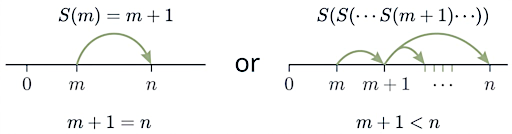

> **Descripción del esquema:** Dos escenarios en la recta numérica.
> 1. Un salto exacto: $m \to n$, donde $m+1 = n$.
> 2. Múltiples saltos: $m \to m+1 \to \dots \to n$, donde $m+1 < n$.

**Conclusión evidente:** $m < m + 1$.
El elemento $m$ solo puede ser estrictamente menor que su primer sucesor. $m$ es el último ancestro (el "padre") de $m+1$.

In [ ]:
struct Orderedset{T}
    naturales::Set{T}
    orden::Set{Tuple{T,T}}
end

In [ ]:
# Constructor de Orderedset
function Orderedset(ℕ::Set{T}, predicado::Function) where T
    ≼ = Set(
        (m,n) for m ∈ ℕ for n ∈ ℕ
        if predicado(m,n)
        )
    return Orderedset{T}(ℕ, ≼)
end

Orderedset

In [ ]:
# m≤n ⟹ ∃p∈N,m+p=n
pred(m::Int, n::Int) = any(
    [m ≤ n && any(m∔p==n) for p ∈ ℕ]
    )
var"(ℕ,≼)" = Orderedset(ℕ, pred)
≼ = var"(ℕ,≼)".orden

println(≼)

Set([(0, 3), (4, 6), (0, 4), (5, 5), (7, 8), (7, 10), (8, 9), (4, 7), (1, 9), (2, 8), (2, 10), (10, 10), (3, 9), (2, 2), (0, 1), (0, 8), (0, 10), (4, 5), (0, 2), (1, 3), (9, 10), (7, 7), (5, 9), (1, 4), (2, 6), (3, 3), (3, 4), (2, 7), (6, 9), (0, 6), (1, 1), (0, 7), (8, 8), (8, 10), (1, 8), (4, 9), (1, 10), (1, 2), (2, 5), (3, 8), (3, 10), (0, 5), (1, 6), (7, 9), (5, 8), (4, 4), (5, 10), (1, 7), (3, 6), (2, 9), (6, 8), (6, 10), (3, 7), (5, 6), (0, 9), (1, 5), (4, 8), (9, 9), (4, 10), (5, 7), (6, 6), (3, 5), (2, 3), (0, 0), (2, 4), (6, 7)])


## Compatibilidad de $\le$ con $(\mathbb{N}, +, \cdot)$

La relación de orden es compatible y no "rompe" las operaciones aritméticas básicas de suma y producto. Para $\forall m, n, p \in \mathbb{N}$, si $m \le n$ ($m$ es ancestro de $n$):

1.  **Con la suma:** $$m + p \le n + p$$
Si saltamos $p$ generaciones adelante en ambos términos, $m+p$ seguirá siendo ancestro de $n+p$ (o serán el mismo).
2.  **Con el producto:** $$m \cdot p \le n \cdot p$$
Si hacemos $p$ saltos de tamaño $m$ y $n$ respectivamente, $m \cdot p$ seguirá siendo ancestro de $n \cdot p$ (o el mismo).



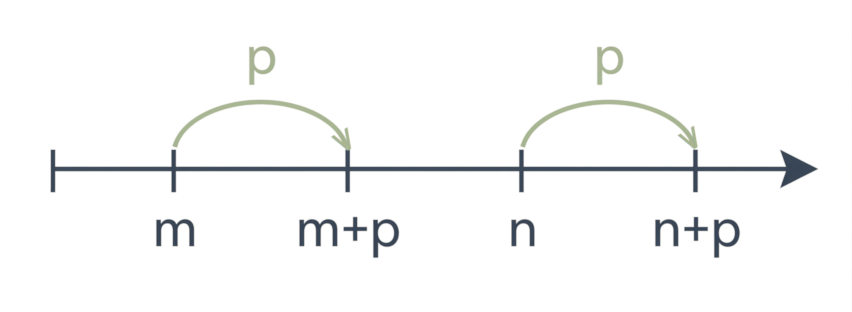

> **Descripción del esquema:** Una recta que muestra cómo la distancia relativa o la precedencia se mantiene cuando los intervalos se desplazan por un factor $p$.

## ¿Por qué $\le$ es una Relación de Orden Total?

La relación $\le$ define un orden total porque cumple con las tres propiedades fundamentales de las relaciones de orden, basándose en la idea de que $\mathbb{N}$ es una "dinastía de hijos únicos con un ancestro común cero".

### 1. Propiedad Reflexiva ($m \le m$)
Si hay $0$ generaciones de distancia ($p = 0$):
$$m + 0 = n \implies m = n$$
Todo elemento es "ancestro" de sí mismo a $0$ generaciones.

### 2. Propiedad Antisimétrica ($m \le n \land n \le m \implies m = n$)
Si $m$ es ancestro de $n$ y, a la vez, sucesor de $n$, es porque hay cero generaciones entre ellos.
Si $m \le n \implies m + p = n$ (hay $p$ generaciones entre $m$ y $n$)
Si $n \le m \implies n + q = m$ (hay $q$ generaciones entre $n$ y $m$)

Reemplazando $n$ en la segunda ecuación:
$$(m + p) + q = m \implies m + (p + q) = m + 0$$
En los números naturales, para que el resultado de una suma sea el mismo operando, es decir, no lo altere, uno de los operandos debe ser cero. Por lo tanto, $p + q = 0 \implies p = 0 \land q = 0$.
Concluyendo:
$$m + 0 = n \implies m = n$$

### 3. Propiedad Transitiva ($m \le n \land n \le r \implies m \le r$)
Si $m$ es ancestro de $n$, y $n$ es ancestro de $r$, lógicamente $m$ es ancestro de $r$.
Sabemos que:

$$m + p = n,$$

$$n + q = r$$

Reemplazando $n$:
$$(m + p) + q = r \implies m + (p + q) = r$$
Es decir, existen exactamente $p+q$ generaciones entre $m$ y $r$.


## Demostración: El Orden $\le$ es Total

Que el orden sea total significa que:
$$\forall m, n \in \mathbb{N} \mid m \le n \lor n \le m$$
Al tomar dos elementos cualquiera de $\mathbb{N}$, uno es ancestro del otro, el otro es sucesor del primero, o ambos son iguales. No existe una cuarta posibilidad.

**Demostración por Inducción (sobre $n$):**

* **Paso 1 (Caso semilla $n=0$):**
    Comparamos un natural $m$ con el primer ancestro $0$.
    * Si $m \le 0 \implies m + p = 0 \implies m = p = 0$. (Es evidente que $0$ no tiene ancestros).
    * Si $m \ge 0 \implies 0 + p = m \implies p = m$. ($0$ es ancestro de todos, hay $m$ generaciones entre ellos).
* **Paso 2 (Hipótesis Inductiva):**
    Asumimos cierto para $n$: $m \le n \implies m+p=n$ o bien $m \ge n \implies n+q=m$.
* **Paso 3 (Caso Sucesor $n+1$):**
    Evaluamos la relación con $n+1$.
    * Si $m \le n$, por propiedad transitiva: $m \le n < n+1 \implies m < n+1$. (El sucesor de $n$ es estrictamente sucesor de $m$).
    * Si $m \ge n$, el sucesor $n+1$ puede ser igual a $m$ (si estaban a una generación de distancia, $m = n+1$) o $m$ sigue siendo ancestro (si estaban a más generaciones, $m > n+1$).
    
En cualquier caso, se preserva que $m \ge n+1$ $\lor$ $m < n+1$.

## Consecuencias Estructurales del Orden en $\mathbb{N}$

De todo lo establecido anteriormente, derivamos cuatro propiedades fundamentales del conjunto de los Naturales:

### 1. $\mathbb{N}$ no tiene máximo
$$\exists M \in \mathbb{N} \mid a \le M, \; \forall a \in \mathbb{N} \text{ es Falso.}$$
Esto contradice el Axioma 2 de Peano, el cual establece que todo $n \in \mathbb{N}$ tiene un único sucesor $S(n) = n+1$ que también pertenece a $\mathbb{N}$.
*No existe el sucesor de todos los sucesores* (aunque sí existe el ancestro de todos los ancestros, que es $0$).

### 2. Existen intervalos abiertos vacíos
$$\forall n \in \mathbb{N} \mid (n, n+1) = \emptyset$$
No existen "generaciones intermedias" entre un padre $n$ y su hijo/sucesor $n+1$. No hay ningún elemento natural en la mitad geométrica o conceptual entre ambos.



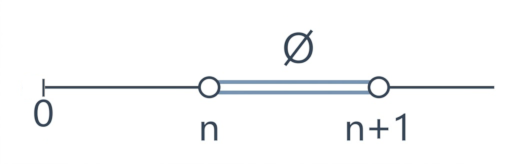

> **Descripción del esquema:** Una recta numérica resaltando un elemento $n$ y su sucesor $n+1$, con un símbolo de conjunto vacío ($\emptyset$) entre ellos, ilustrando la ausencia de valores intermedios.

### 3. $(\mathbb{N}, \le)$ es un conjunto Bien Ordenado
$$\forall A \subset \mathbb{N} \mid \exists m \in A, m \le x, \; \forall x \in A \text{ es Verdad.}$$
Cualquier subconjunto $A$ de elementos de $\mathbb{N}$ siempre tendrá un elemento que es ancestro de todos los otros en ese subgrupo. A este elemento se le llama el mínimo, $\min(A) = m$. Esto ocurre porque $\mathbb{N}$ es un linaje lineal y el $0$ actúa como cota inferior absoluta.

### 4. Todo subconjunto acotado superiormente tiene un Máximo
$$\forall A \subset \mathbb{N} \mid \text{Si } x \le M \text{ para un } M \notin A, \; \exists \max(A) \in A$$
Si tomamos un subconjunto $A \subset \mathbb{N}$ y sabemos que existe una cota superior (un sucesor externo $M+1$ que es mayor a todos los elementos de $A$), es evidente que dentro del propio conjunto $A$ habrá un elemento que sea generacionalmente el más cercano a ese límite externo. Ese elemento será el $\max(A)$.

In [ ]:
import Pkg; Pkg.add("Combinatorics")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Combinatorics ─ v1.1.0
    Updating `~/.julia/environments/v1.11/Project.toml`
  [861a8166] + Combinatorics v1.1.0
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [861a8166] + Combinatorics v1.1.0
Precompiling project...
   7466.8 ms  ✓ Combinatorics
  1 dependency successfully precompiled in 19 seconds. 474 already precompiled.


In [ ]:
using Combinatorics

ℕ = var"(ℕ,≼)".naturales
≼ = var"(ℕ,≼)".orden
var"≼⁻¹" = Set((tup[2], tup[1]) for tup ∈ ≼)

# ∀A⊂N: Todos los posibles subconjuntos
𝓟(ℕ) = Set([Set(n) for n in powerset(collect(ℕ))])

# Es un conjunto bien ordenado?
function is_woset(var"(ℕ,≼)"::Orderedset{T}) where T
    ℕ = var"(ℕ,≼)".naturales
    ≼ = var"(ℕ,≼)".orden
    propo_accum = Bool[]
    ∅ = Set{T}()
    for A ∈ setdiff(𝓟(ℕ), Set([∅]), Set([ℕ]))
        # ∃m∈A, m≤x, ∀x∈A
        predicado_M = [((m, x) ∈ ≼) for x ∈ A, m ∈ A]
        ∀x = map(all, eachrow(predicado_M))
        ∃M = any(∀x)
        push!(propo_accum, ∃M)
    end
    ∀A = all(propo_accum)
    return ∀A
end

# Definirmos el producto: A×B={(x,y)|x∈A,y∈B}
function ×(A, B)
     return Set((x, y) for x ∈ A for y ∈ B)
end

# Definimos la composicion
function Base.:∘(𝓢::Set{Tuple{T,T}}, 𝓡::Set{Tuple{T,T}}, ℕ::Set) where T
    # 𝓢∘𝓡 = {(x, z) ∈ ℕ² ∃y ∈ ℕ | (x, y) ∈ 𝓡 ∧ (y, z) ∈ 𝓢}
    predicado_M = [(x, y) ∈ 𝓡 && (y, z) ∈ 𝓢 for (x,z) ∈ ℕ × ℕ, y ∈ ℕ]
    ∃y = map(any, eachrow(predicado_M))
    return Set{Tuple{T,T}}(collect(ℕ × ℕ)[∃y])
end

# 2. Comprobamos que cumple con las tres propiedades
es_reflexiva = Set([(a, a) for a ∈ ℕ]) ⊆ ≼
es_antisimetrica = ∩(var"≼⁻¹", ≼) ⊆ Set([(a, a) for a ∈ ℕ])
es_transitiva = ∘(≼, ≼, ℕ) ⊆ ≼
Universo = ℕ × ℕ
es_orden_total = ∪(var"≼⁻¹", ≼) == Universo
es_bien_ordenado = is_woset(var"(ℕ,≼)")

println(":: ¿es reflexiva?: $(es_reflexiva), \n:: ¿es antisimetrica?: $(es_antisimetrica), \n:: ¿es transitiva?: $(es_transitiva)")
println(":: ¿es una R. Orden total?: $(es_orden_total)")
println(":: ¿es bien ordenado?: $(es_bien_ordenado)")

:: ¿es reflexiva?: true, 
:: ¿es antisimetrica?: true, 
:: ¿es transitiva?: true
:: ¿es una R. Orden total?: true
:: ¿es bien ordenado?: true


# Conjuntos Finitos

Los conjuntos finitos simbolizan la **acción de contar**. Utilizan los intervalos del conjunto ordenado $(\mathbb{N}, \le)$ como una "regla de medida" 📏 para determinar el número exacto de elementos de un conjunto dado $A$.

## ¿Qué es un conjunto finito?

Un conjunto finito es, en realidad, un objeto compuesto por dos partes fundamentales:
1. Un conjunto cualquiera $A$.
2. Un subconjunto ordenado que sirve como regla de medida, específicamente un intervalo cerrado $[1, n] \subset (\mathbb{N}, \le)$.

El acto de contar se simboliza mediante una relación de aplicación **biyectiva** entre ambos conjuntos:
$$f: A \to [1, n]_{\mathbb{N}}$$

Dado que $f$ es biyectiva, existe una **equipotencia** entre los dos conjuntos en cuestión (es decir, $A \equiv [1, n]_{\mathbb{N}}$). Por lo tanto, podemos definir su tamaño mediante el cardinal:
$$\text{Card}(A) = \text{Card}([1, n]) = n$$

> **Definición Formal:** Un conjunto $A$ es finito si es vacío ($A = \emptyset$) o si es equipotente con un intervalo cerrado de $\mathbb{N}$ ($A \equiv [1, n]_{\mathbb{N}}$). En caso contrario, el conjunto se considera infinito.

### Visualización del acto de contar

Asignarle a un conjunto una regla de medición implica emparejar cada elemento con un número natural.



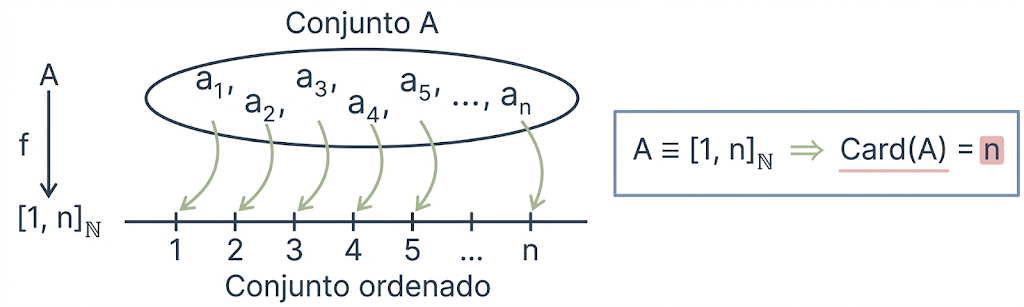

> **Descripción del esquema:** Se ilustra un conjunto $A$ con los elementos $\{a_1, a_2, a_3, a_4, a_5, \dots, a_n\}$. De cada elemento sale una flecha de aplicación biyectiva ($f$) hacia un "conjunto ordenado" que actúa como regla, el cual es el intervalo $[1, n]_{\mathbb{N}} = \{1, 2, 3, 4, 5, \dots, n\}$. Esta relación uno a uno demuestra que $A \equiv [1, n]_{\mathbb{N}}$, implicando que $\text{Card}(A) = n$.

# Propiedades de los Intervalos Cerrados $[1, n]_{\mathbb{N}}$

Entre distintas "reglas de medida" (intervalos), existen relaciones que permiten determinar si una regla es mayor, menor o igual que otra. Esto depende del tipo de aplicación $f$ existente entre dichos intervalos cerrados en $\mathbb{N}$.

### 1. Aplicación Inyectiva ($f$)
Sean $n, m \in \mathbb{N}^*$ y una función $f: [1, n] \to [1, m]$.
Si $f$ es **inyectiva**, entonces:
$$\text{Card}([1, n]) \le \text{Card}([1, m]) \implies n \le m$$
> **Analogía de nidos y palomas:** Si hay $n$ palomas y $m$ nidos, al ser $f$ inyectiva (cada paloma en su propio nido, sin compartir), tiene que haber obligatoriamente más nidos que palomas. Como $n + p = m$, habrá $p$ nidos vacíos.

### 2. Aplicación Biyectiva ($f$)
Si $f: [1, n] \to [1, m]$ es **biyectiva**, entonces:
$$\text{Card}([1, n]) = \text{Card}([1, m]) \implies n = m$$
> **Analogía:** Hay exactamente el mismo número de palomas que de nidos. Por tanto, en la ecuación $n + p = m$, la diferencia es $p = 0$, lo que significa que hay cero nidos vacíos.

### 3. Unicidad del Cardinal
Si $A$ es un conjunto finito, entonces es equipotente con un intervalo cerrado específico de $\mathbb{N}$ ($A \equiv [1, n]_{\mathbb{N}}$). Por tanto:
$$\text{Card}(A) = \text{Card}([1, n]) = n$$
El cardinal de un conjunto finito es **único**; un conjunto no puede tener dos tamaños distintos simultáneamente.

Como corolario, cualquier aplicación de una regla de medición a sí misma ($f: [1, n] \to [1, n]$) es siempre equipotente, es decir, es biyectiva y su cardinal es $\text{Card}([1, n]) = n$. Si tienes la misma cantidad de nidos que de palomas, cualquier forma de asignar las palomas sin repetir nido llenará automáticamente todos los nidos.

### 4. Existencia del Máximo
Sea $A \subset \mathbb{N}$ un subconjunto no vacío ($A \neq \emptyset$).
Entonces, $A \equiv [1, n]$ es finito **si y solo si** $A$ está acotado superiormente.
* Un conjunto finito siempre tiene un máximo (según la relación de orden).
* Si tiene un máximo, es finito.

Esto ocurre porque si $\text{Card}(A) = n$ en $\mathbb{N}$, siempre existirá un sucesor $n+1$. Por lo tanto, ese sucesor actúa como la cota superior mínima de $A$.

## Consecuencias Estructurales
Derivado de las propiedades anteriores, establecemos que:
* $\mathbb{N}$ es un conjunto infinito.
* Todo subconjunto que pertenezca a un subconjunto finito de $\mathbb{N}$ es también finito.
* La unión de dos conjuntos finitos da como resultado otro conjunto finito.
* El complemento de un subconjunto finito (respecto a $\mathbb{N}$) es un conjunto infinito.


# Subconjuntos de un Conjunto Finito

La regla fundamental aquí es de conservación: *No se pueden crear ni destruir elementos en un conjunto finito*.

### 1. El subconjunto es estrictamente menor
*Un pedazo de la tarta siempre es más pequeño que la tarta completa.*

Sea $A \subset B \equiv [1, n]$, donde $B$ es un conjunto finito. Si $A \neq B$ (subconjunto propio), entonces $A$ es finito y se cumple que:
$$\text{Card}(A) < \text{Card}(B)$$
Esto significa que la regla de medida (el intervalo cerrado equipotente) de $A$ no puede ser más grande que la regla de medida de $B$. Intuitivamente: no pueden haber infinitas cosas dentro de una caja finita.



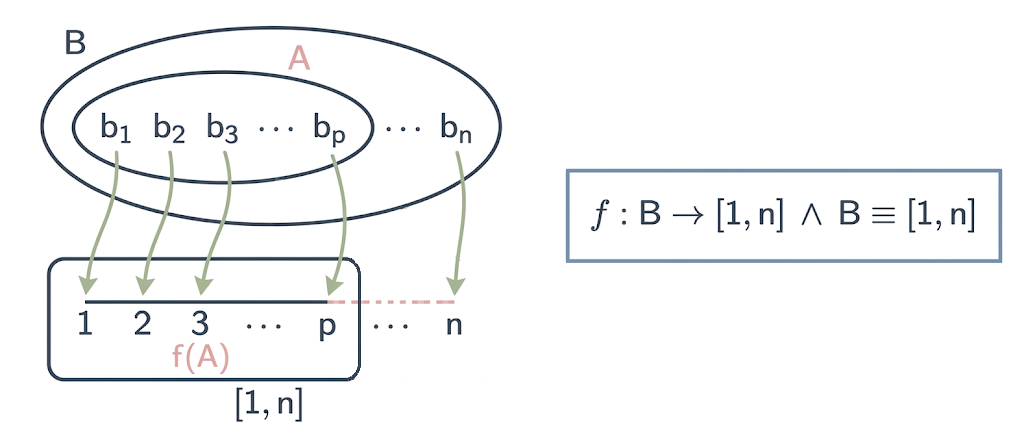

> **Descripción del esquema:** Se muestra un conjunto grande $B$ que contiene un subconjunto más pequeño $A$. Los elementos de $A$ van de $b_1$ a $b_p$, mientras que $B$ continúa hasta $b_n$. Se aplica una función $f: B \to [1, n]$, sabiendo que $B \equiv [1, n]$. Al proyectar $A$ mediante esta misma función, obtenemos $f(A) \subset [1, n]$, y específicamente $f(A) = [1, p]$. Es evidente visual y lógicamente que $p < n$, demostrando que $\text{Card}(A) < \text{Card}(B)$.

### 2. Contención de Imágenes (Principio del Palomar)
*El número de palomas sentadas en nidos no puede superar al número total de palomas.*

Sea $A$ un conjunto finito ($A \equiv [1, n]$) y una aplicación cualquiera $f: A \to B$. Entonces, la imagen de la función está contenida en el codominio ($f(A) \subset B$). Además, $f(A)$ es un conjunto finito y:
$$\text{Card}(f(A)) \le \text{Card}(A)$$

* **Si $f$ es Inyectiva:** $\text{Card}(f(A)) = \text{Card}(A)$.
  > Es decir, finitas palomas $A$ ocupan finitos nidos $B$. Las palomas ya sentadas en los nidos $f(A)$ serán iguales al número total de palomas (si no comparten nido).
* **Si $f$ NO es inyectiva:** El número de nidos ocupados será estrictamente menor al número de palomas (ya que comparten nidos).

### 3. Aplicación Sobreyectiva
Si una función $f: A \to B$ es **sobreyectiva**, entonces el codominio está completamente cubierto y:
$$\text{Card}(B) \le \text{Card}(A)$$
*(Nota: Si además es biyectiva, entonces $\text{Card}(B) = \text{Card}(A)$).*
> En términos de nuestra analogía: para que *todos* los nidos queden ocupados (sobreyectiva), no puede haber físicamente más nidos que palomas disponibles.

## Consecuencias de las Aplicaciones en Conjuntos Finitos
### 1. Equivalencia de Condiciones de Aplicación
¿Cumplir con una condición lleva a que se cumplan las demás?
Sean $A$ y $B$ conjuntos finitos equipotentes entre sí ($A \equiv B \equiv [1, n]_{\mathbb{N}}$) y sea una aplicación $f: A \to B$.

Bajo estas premisas, las siguientes afirmaciones son **equivalentes**:
* i) $f$ es inyectiva
* ii) $f$ es sobreyectiva
* iii) $f$ es biyectiva

> **Analogía:** Si exiges que $f$ sea inyectiva (estrictamente una paloma por nido), dado que hay exactamente la misma cantidad de nidos y palomas, la función será obligatoriamente sobreyectiva (todos los nidos se ocuparán) y, por tanto, biyectiva. Cumplir con una condición hace que automáticamente se cumplan las demás.

*Nota:* Lo anterior es **falso** si $A$ y $B$ son conjuntos infinitos.

# Homomorfismos entre Conjuntos y Aritmética en $\mathbb{N}$

Sabemos que en $\mathbb{N}$ existen operaciones internas bien definidas, como la suma ($+$) y el producto ($\cdot$). También sabemos que un conjunto finito es aquel equipotente con un intervalo cerrado de $\mathbb{N}$.

Existe una correspondencia estructural profunda. Las operaciones algebraicas de conjuntos (como la unión $\cup$ para formar la estructura $(A, \cup)$) son **homomórficas** a las operaciones en los intervalos numéricos ($([1, n], +)$).

Dado $A \equiv [1, n]$, existe un homomorfismo:
$$(A, \cup) \xrightarrow{f} ([1, n], +)$$

**Conclusión:**
Las operaciones definidas por los Axiomas de Peano y la función sucesor en $\mathbb{N}$ (como $+$, $\cdot$, $a^n$) tienen homomorfismos directos con las operaciones típicas de la teoría de conjuntos. Dicho puente u homomorfismo es precisamente la función que llamamos:

> **Cardinal**: $\text{Card}(A)$.


## 2. La Unión es la Suma ($+$)
Sean $A$ y $B$ dos conjuntos finitos **disyuntos** ($A \cap B = \emptyset$), entonces $A \cup B$ es un conjunto finito.

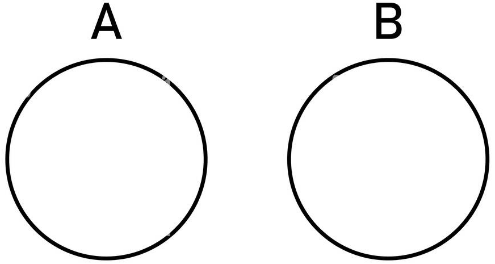

> **Descripción del esquema:** Dos círculos separados que representan los conjuntos $A$ y $B$ sin ninguna intersección entre ellos.

El homomorfismo se expresa como:
$$\text{Card}(A \cup B) = \text{Card}(A) + \text{Card}(B)$$

Si $\text{Card}(A) = n$ mediante $f: A \to [1, n]$ y $\text{Card}(B) = m$ mediante $g: B \to [1, m]$, entonces $\text{Card}(A \cup B) = n + m$ mediante $h: A \cup B \to [1, n+m]$.

**Demostración por inducción (sobre $B$):**
* **Paso 1:** $B = \emptyset$ y $\text{Card}(A) = m$.
$$A \cup B = A \cup \emptyset = A$$
Por tanto:
$$\text{Card}(A \cup B) = \text{Card}(A) + \text{Card}(B)$$
$$\text{Card}(A) = \text{Card}(A) + 0 \implies m = m + 0$$
Esto es coherente con la definición de suma en los Axiomas de Peano.
* **Paso 2 (Hipótesis):** $\text{Card}(B) = n$, $\text{Card}(A) = m$ y $\text{Card}(A \cup B) = m + n$.
* **Paso 3 (Sucesor):** $\text{Card}(B) = n + 1$ y $\text{Card}(A) = m$.
Sea $B = B' \cup \{b\}$ donde $\text{Card}(B') = n$.
$$A \cup B = A \cup (B' \cup \{b\})$$
$$\text{Card}(A \cup B) = \text{Card}(A) + \text{Card}(B') + \text{Card}(\{b\}) = m + n + 1$$
Pasando a la notación de función sucesor $S$:
$$m + (n + 1) = m + S(n)$$
$$(m + n) + 1 = S(m + n)$$
Esto refleja exactamente la definición de la suma con Axiomas de Peano: $m + S(n) = S(m + n)$.

## 3. El problema de contar dos veces (Principio de Inclusión-Exclusión)
Sean $A$ y $B$ dos conjuntos finitos en conjunción, es decir, comparten elementos ($A \cap B \neq \emptyset$).

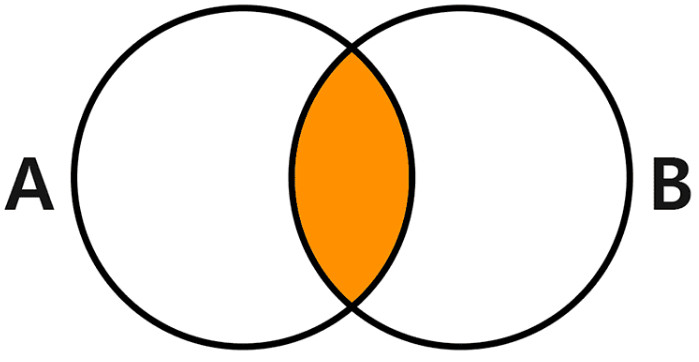


> **Descripción del esquema:** Diagrama de Venn con dos círculos $A$ y $B$ superpuestos, mostrando una región de intersección en el medio.

En este caso, $A \cup B$ y $A \cap B$ son ambos conjuntos finitos y se cumple:
$$\text{Card}(A \cup B) + \text{Card}(A \cap B) = \text{Card}(A) + \text{Card}(B)$$
> Es decir, si cuentas todos los elementos de $A$ y luego todos los de $B$ y los sumas, los elementos de la intersección $A \cap B$ se habrán contado dos veces.

**Demostración:**
Descomponemos la unión en conjuntos disyuntos:
$$A \cup B = A \cup (B \setminus A)$$
Como $A \cap (B \setminus A) = \emptyset$ (son disyuntos), aplicamos el homomorfismo de la suma:

1. $\text{Card}(A \cup B) = \text{Card}(A) + \text{Card}(B \setminus A)$

Por otro lado, descomponemos $B$:
$$B = (B \setminus A) \cup (A \cap B)$$
Como $(B \setminus A) \cap (A \cap B) = \emptyset$, aplicamos el homomorfismo:

2. $\text{Card}(B \setminus A) + \text{Card}(A \cap B) = \text{Card}(B)$

Sumamos las ecuaciones resultantes 1 y 2:
$$\text{Card}(A \cup B) + \require{cancel}\cancel{\text{Card}(B \setminus A)} + \text{Card}(A \cap B) = \text{Card}(A) + \require{cancel}\cancel{\text{Card}(B \setminus A)} + \text{Card}(B)$$

*Nota de la transcripción:* Sustituyendo algebraicamente usando la propiedad cancelativa obtenemos directamente:
$$\text{Card}(A \cup B) + \text{Card}(A \cap B) = \text{Card}(A) + \text{Card}(B)$$

## 6. El Producto Cartesiano es la Multiplicación ($\cdot$)
Sean $A$ y $B$ dos conjuntos finitos, entonces su producto cartesiano $A \times B$ es un conjunto finito.
El homomorfismo se define como:
$$\text{Card}(A \times B) = \text{Card}(A) \cdot \text{Card}(B)$$

**Demostración por inducción (sobre $B$):**
* **Paso 1:** $\text{Card}(B) = 1$, es decir $B = \{b\}$.
Combinar muchos elementos $A = \{a_1, a_2, \dots, a_n\}$ con un solo elemento $\{b\}$ no cambia el número de tuplas.
Es obvio que $A \times B \equiv A$ porque tendrían la misma cantidad de elementos.
$$\text{Card}(A \times B) = \text{Card}(A) \cdot \text{Card}(\{b\}) = \text{Card}(A) \cdot 1$$
Lo que equivale al axioma de Peano $m = m \cdot 1$.

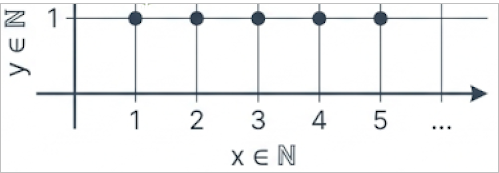

* **Paso 2 (Hipótesis):** Sea $\text{Card}(B') = n \implies \text{Card}(A \times B') = \text{Card}(A) \cdot \text{Card}(B')$.
* **Paso 3 (Sucesor):** Suponemos $\text{Card}(B) = n+1$. Por tanto, $B = B' \cup \{b\}$ (tiene un elemento más que $B'$).
$$A \times B = A \times (B' \cup \{b\}) = (A \times B') \cup (A \times \{b\})$$
Como $(A \times B') \cap (A \times \{b\}) = \emptyset$ (son disyuntos), aplicamos el homomorfismo de la suma:
$$\text{Card}(A \times B) = \text{Card} \left( (A \times B') \cup (A \times \{b\}) \right) = \text{Card}(A \times B') + \text{Card}(A \times \{b\})$$
Usando la hipótesis del paso 2 y aplicando la Propiedad Distributiva:
$$= (\text{Card}(A) \cdot n) + (\text{Card}(A) \cdot 1) = \text{Card}(A) \cdot (n + 1)$$
Esto es idéntico a la definición recursiva del producto con Axiomas de Peano: $m \cdot S(n) = m \cdot n + m$.

## 7. El Número de Funciones Posibles es la Potenciación ($b^a$)
Sean $A$ y $B$ dos conjuntos finitos no nulos, con $a = \text{Card}(A)$ y $b = \text{Card}(B)$.
Sea $\mathcal{F}(A, B)$ el conjunto de todas las aplicaciones posibles (inyectivas, sobreyectivas, u otras) $f: A \to B$.

El homomorfismo se calcula como:
$$\text{Card}(\mathcal{F}(A, B)) = \text{Card}(B)^{\text{Card}(A)} = b^a$$
> **Interpretación:** Existen $b^a$ formas de combinar $a$ palomas con $b$ nidos, permitiendo compartir nido.

**Casos Especiales:**
* $B = \emptyset \implies \text{Card}(\mathcal{F}(A, \emptyset)) = 0^a = 0$ (No existe aplicación posible).
* $A = \emptyset \implies \text{Card}(\mathcal{F}(\emptyset, B)) = b^0 = 1$ (Existe una única aplicación: la Aplicación Vacía).

**Demostración por Inducción:**
* **Paso 1:** Sea $A = \{a\}$ y $\text{Card}(A) = 1$.
Por cada elemento $a \in A$ puedo dirigir $\text{Card}(B)$ flechas (imágenes posibles) a los elementos de $B$.
Si $\text{Card}(B) = b$, entonces $\text{Card}(\mathcal{F}(A, B)) = b^1 = b$.
*(Si solo hay una paloma, existen $b$ posibilidades de nido).*
* **Paso 2 (Hipótesis):** $\text{Card}(B^A) = b^a$ si $a = \text{Card}(A)$.
* **Paso 3 (Sucesor):** Sea $\text{Card}(A') = a + 1$, donde $A' = A \cup \{q\}$ (añadimos una paloma más).
Si añadimos una paloma, aumentan las posibilidades en un factor de $b$ (cada paloma nueva tiene $b$ posibilidades porque pueden compartir nido). Usando la hipótesis:
$$\text{Card}(B^{A'}) = b^{a+1} = b^a \cdot b$$
Esto es igual a la definición recursiva de la potenciación de Peano: $a^{S(n)} = a^n \cdot a$.

## 8. Conjunto de Partes $\mathcal{P}(A)$
Cuando solo hay dos opciones posibles (binario: *pertenece* o *no pertenece*), usamos base 2.
Sea $A$ un conjunto finito, el número posible de subconjuntos de $A$ (su conjunto potencia $\mathcal{P}(A)$) es:
$$\text{Card}(\mathcal{P}(A)) = 2^{\text{Card}(A)}$$

> **Intuición:** Es como si para cada paloma $a = \text{Card}(A)$ hubiese solo dos nidos posibles $b = \text{Card}(\{0, 1\}) =2$ y por lo que vimos de la potenciación $\text{Card}(\mathcal{F}(A, \{0, 1\})) = b^a = 2^{\text{Card}(A)}$

**Razonamiento mediante funciones características:**
Para cada $x \in A$ existen dos opciones frente a una parte $P \in \mathcal{P}(A)$: $x \in P$ o $x \in A \setminus P$.
Esto se expresa con la **función característica** $\chi_P: A \to \{0, 1\}$.
Por tanto, las funciones características pertenecen al conjunto $\mathcal{F}(A, \{0, 1\})$.

¿Cuántas funciones $\chi_P$ hay? Las mismas que partes en $\mathcal{P}(A)$.
$$\text{Card}(\mathcal{P}(A)) = \text{Card}(\mathcal{F}(A, \{0, 1\})) = 2^{\text{Card}(A)}$$

Es decir existen $2^{\text{Card}(A)}$ posibles aplicaciones características $\chi_P$:

$\mathcal{P}(A) = \{ ∅, a_1, a_2, ⋯, \{a_1, a_2\}, \{a_2, a_1\} ⋯, A \}$

$\mathcal{F}(A, \{0, 1\})= \{ \chi_\emptyset, \chi_{a_1}, \chi_{a_2}, \cdots, \chi_{\{a_1, a_2\}}, \chi_{\{a_2, a_1\}}, \cdots, \chi_A \}$

## 9. Permutación (Variaciones sin repetición)
Sea $\mathcal{J}(A, B)$ el conjunto de todas las posibles **aplicaciones inyectivas** $j: A \to B$. Si $A$ y $B$ son finitos, $\mathcal{J}(A, B)$ es finito.
Si $n = \text{Card}(A)$ y $m = \text{Card}(B)$:
$$\text{Card}(\mathcal{J}(A, B)) = V_{m,n} = m \cdot (m - 1) \cdot \dots \cdot (m - (n - 1)) = \frac{m!}{(m - n)!}$$

> **Intuición:** Cuando exigimos inyectividad (no se puede compartir nido):
> * La primera paloma tiene $m$ posibilidades.
> * La segunda paloma tiene $m - 1$ posibilidades (un nido ya está ocupado).
> * La tercera paloma tiene $m - 2$ posibilidades (dos nidos ya fueron ocupados)
> * La última paloma (la número $n$) tiene $m - (n - 1)$ posibilidades.

Siendo $n$ el número de palomas y $m$ el número de nidos

**Caso Biyectivo:**
Si el número de palomas y nidos es el mismo ($\text{Card}(A) = \text{Card}(B) = n$), el conjunto de todas las aplicaciones biyectivas posibles $\mathcal{B}(A, B)$ tiene un cardinal de:
$$\text{Card}(\mathcal{B}(A, B)) = n!$$

> **Intuición:** Cuando exigimos biyectividad:
> * La primera paloma tiene $n$ posibilidades.
> * La segunda paloma tiene $n - 1$ posibilidades (un nido ya está ocupado).
> * La tercera paloma tiene $n - 2$ posibilidades (dos nidos ya fueron ocupados)
> * La última paloma (la número $n$) tiene $1$ posibilidad. Ya que, hay la misma cantidad de nidos que de palomas.

## 10. Combinatoria (Nidos llenos vs. Nidos vacíos)
Son conjuntos de un tamaño exacto $n$.
Sea $A$ un conjunto finito con $\text{Card}(A) = m$ y sea $0 \le n \le m$. El número de subconjuntos $B \subset A$ que posee exactamente $n$ elementos ($\text{Card}(B) = n$) es el **Coeficiente Binomial**:
$$C_{m,n} = \binom{m}{n} = \binom{m}{m-n}$$

> Es decir, por cada $n$ nidos llenos, habrá invariablemente $m-n$ nidos vacíos siendo $m$ el total de nidos disponibles.

**Relación con las variaciones:**
$$\binom{m}{n} = \frac{V_{m,n}}{n!} = \frac{m!}{n! \cdot (m - n)!}$$

$V_{m,n}$ cuenta "casos de más" porque le importa el orden (qué paloma ocupa qué nido). $C_{m,n}$ solo se fija en qué nido está ocupado, independientemente de la paloma. Como hay $n!$ formas de reorganizar las palomas dentro de los mismos $n$ nidos, dividimos $V_{m,n}$ entre el factor de redundancia $n!$.

**Biyección perfecta en la combinatoria:**
Se genera una biyección perfecta $f: \mathcal{P}(A) \to \mathcal{P}(A)$ entre nidos llenos y vacíos.
* **Dominio:** Partes de $A$ de tamaño $n \implies \{P \in \mathcal{P}(A) \mid \text{Card}(P) = n\}$
* **Imagen:** $f(P) = A \setminus P$ (el complemento, que representa los nidos vacíos de tamaño $m-n$).

Por tanto, $f$ es una aplicación de una de las partes $P \in \mathcal{P}(A)$ hacia su complemento $A \setminus P$, dicho complemento es único para cada parte $P$ y, ademas, es un elemento de partes de A *i.e.* $A \setminus P \in \mathcal{P}(A)$ por tanto $f$ es **biyectiva** por definición.

Existen $\binom{m}{n}$ formas de elegir $n$ nidos llenos dentro de un conjunto de $m$ nidos, y por cada elección de $n$ nidos llenos, existirá una correspondencia unívoca con un conjunto de $m-n$ nidos vacíos. Por tanto, $\mathcal{B}(\mathcal{P}(A), \mathcal{P}(A))$ el conjunto de todas las posibles aplicaciones biyectivas entre $\mathcal{P}(A)$ las partes de A (entre la parte $P$ y su contraparte o complemento $A \setminus P$) tiene un número finito de aplicaciones $f \in \mathcal{B}(\mathcal{P}(A), \mathcal{P}(A))$ que es exactamente:

$$\text{Card}\left(\mathcal{B}(\mathcal{P}(A), \mathcal{P}(A))\right) = \binom{m}{n}$$





# Conjuntos Infinitos

Al adentrarnos en los conjuntos infinitos, nuestra clásica analogía de "nidos y palomas" (Principio del Palomar) se rompe. La herramienta conceptual adecuada aquí es el famoso **"Hotel infinito de Hilbert"**.

## El Hotel de Hilbert
Imaginemos un hotel con infinitas habitaciones numeradas secuencialmente ($1, 2, 3, \dots, n, n+1, \dots$). El hotel tiene un solo huésped por habitación; es decir, **todas sus habitaciones están llenas**. Sin embargo, paradójicamente, siempre hay espacio para nuevos huéspedes.

**El mecanismo:**
Si llega un nuevo huésped, se le pide a todos los huéspedes actuales que se muevan una habitación hacia la derecha (el de la 1 a la 2, el de la 2 a la 3, y el de la $n$ a la $n+1$). Esto libera la habitación No. 1 para el nuevo huésped.
Dado que el hotel es infinito, este movimiento "nunca terminaría" (mientras el nuevo huésped ya tiene su habitación, los huéspedes más lejanos aún se estarían cambiando infinitamente). Lo crucial es que, al final, **ningún huésped queda de forma definitiva sin habitación**. Por tanto, siempre hay espacio para nuevos huéspedes, aunque al mismo tiempo todas las infinitas habitaciones estén llenas.

Matemáticamente, esta analogía se expresa mediante una **aplicación biyectiva** $f: \mathbb{N} \to A$, donde:
$$f(n) = x_n \mid x \in A \land n \in \mathbb{N}$$
Por tanto, $A \equiv \mathbb{N}$ (son equipotentes). Esto permite asignar a cada elemento de $x \in A$ una "habitación" $n \in \mathbb{N}$, estructurando el conjunto de la siguiente forma: $\{x_n \mid n \in \mathbb{N}\}$.

## Conjuntos Finitos vs. Conjuntos Infinitos

* **En conjuntos finitos ($A \equiv [1, n]$):** Si $B \subset A$, una función $f: B \to A$ nunca puede ser biyectiva, solo inyectiva, ya que lógicamente $\text{Card}(B) < \text{Card}(A)$. Es decir, las partes no pueden ser iguales al todo.
* **En conjuntos infinitos ($A \equiv \mathbb{N}$):** Esta intuición se rompe. Si un subconjunto $B \subset A$ es también infinito ($B \equiv \mathbb{N}$), la función $f: B \to A$ **sí es biyectiva**, por lo que $B \equiv A \equiv \mathbb{N}$, a pesar de que $B$ sea un subconjunto estricto de $A$ ($B \subset A$). **La parte puede ser igual de grande al todo**. Un subconjunto puede tener tantos elementos como el conjunto que lo contiene.

**Ejemplo demostrativo: Los Números Pares ($2n$)**
Los números pares son un subconjunto de los naturales ($\{2n \mid n \in \mathbb{N}\} \subset \mathbb{N}$). Sin embargo, hay tantos números pares como números naturales porque ambos conjuntos son infinitos y existe una función biyectiva $f(n) = 2n$ para todo $n \in \mathbb{N}$.
Sus cardinales son exactamente iguales:
$$\text{Card}(\{2n \mid n \in \mathbb{N}\}) = \text{Card}(\mathbb{N}) = \aleph_0 \quad \text{(Aleph sub cero)}$$

## Números Transinfinitos y la Jerarquía de Infinitos

El cardinal $\aleph_0$ es un número **transinfinito**. Junto con otros, conforma el conjunto de los números transinfinitos $\{\aleph_0, \aleph_1, \aleph_2, \dots, \aleph_n, \dots\}$, que representan los cardinales de los conjuntos infinitos.

**¿Todos los conjuntos infinitos tienen el mismo cardinal?**
Hemos dicho que $\mathbb{N}$ y el conjunto de los pares tienen el mismo cardinal ($\aleph_0$) porque son infinitos. Pero **no todos los conjuntos infinitos son "igual de infinitos"**. Existen niveles o jerarquías de infinitos:
$$\aleph_0, \aleph_1, \dots, 2^{\aleph_0}, 2^{2^{\aleph_0}}, \dots$$

Por tanto, hay conjuntos infinitos que **no son biyectivos entre sí**.
*Ejemplo:* El conjunto de partes de $\mathbb{N}$, denotado como $\mathcal{P}(\mathbb{N})$, es un infinito de un orden mayor que $\mathbb{N}$.
$$\text{Card}(\mathcal{P}(\mathbb{N})) = 2^{\text{Card}(\mathbb{N})} = 2^{\aleph_0} \neq \aleph_0$$
Dado que $\mathcal{P}(\mathbb{N}) \not\equiv \mathbb{N}$ (no son equipotentes), no existe biyectividad entre ellos.

### La Jerarquía Visual de Infinitos
$$\text{Card}(\mathbb{N}) < \text{Card}(\mathcal{P}(\mathbb{N})) < \text{Card}(\mathcal{P}(\mathcal{P}(\mathbb{N})))$$
$$\aleph_0 \quad < \quad 2^{\aleph_0} \quad < \quad 2^{2^{\aleph_0}}$$
* $\aleph_0$: Infinito numerable.
* $2^{\aleph_0}$: El Continuo ($\beth_1$).
* $2^{2^{\aleph_0}}$: Partes del Continuo ($\beth_2$).

# Conjuntos Infinitos Numerables ($\aleph_0$)

El infinito numerable, cuyo cardinal es Aleph sub cero ($\aleph_0$), es el primer nivel de infinito (el infinito más pequeño).

> **Definición:** Un conjunto $A$ es "infinito numerable" si es equipotente con los números naturales ($A \equiv \mathbb{N}$), y por tanto, $\text{Card}(A) = \text{Card}(\mathbb{N}) = \aleph_0$.

Dado que $A \equiv \mathbb{N}$, se garantiza que existe una función biyectiva $f: \mathbb{N} \to A$. De manera que $f: n \to x_n \mid x \in A$, definiendo el conjunto como $\{x_n \mid n \in \mathbb{N}\}$. Esto significa que para cada elemento de $A$ existe un **único** elemento en $\mathbb{N}$.
Volviendo a la analogía de Hilbert: $x_n$ es el huésped $x$ asignado a la habitación $n$. Un conjunto es numerable porque a cada elemento $x$ le puedo asociar un único número $n \in \mathbb{N}$; esto es en sí mismo la acción de "contar o numerar" 🤩, representada por la biyección.

## Subconjuntos de Conjuntos Infinitos Numerables
Todo subconjunto $A \subset \mathbb{N}$ de un conjunto infinito numerable **solo puede ser**:
1.  **Conjunto finito:** $A \equiv [1, n]$
2.  **Conjunto infinito numerable:** $A \equiv \mathbb{N}$

No existe una tercera opción. Si $A$ es infinito, siempre será equipotente a $\mathbb{N}$. En otras palabras, no existen subconjuntos infinitos numerables que sean más pequeños que $\mathbb{N}$ y no sean equipotentes con él.

# El Método Diagonal de Cantor

Esta herramienta conceptual nos permite entender, por ejemplo, por qué el producto cartesiano $\mathbb{N}^2 = \mathbb{N} \times \mathbb{N}$ (el plano de números naturales) sigue siendo un conjunto infinito numerable, a pesar de ser de dos dimensiones.

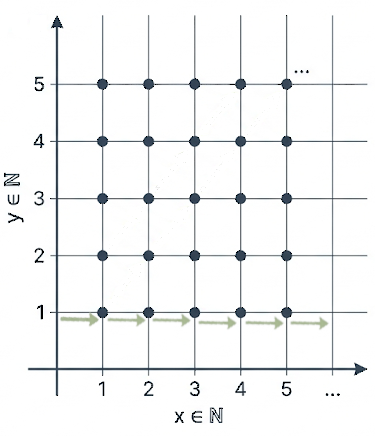

> **Descripción del problema:** Si representamos $\mathbb{N}^2$ como un plano cartesiano (puntos en $x,y$), intentar recorrer todos los puntos fila por fila o columna por columna presenta un problema: si empiezo por la primera fila $(x, 1)$, al ser infinita, nunca terminaría de recorrerla para pasar a la segunda fila. Lo mismo ocurre si avanzo por columnas. La dirección del recorrido es crucial.

Cantor se dio cuenta de este problema y descubrió que la única manera de recorrer ordenadamente todo $\mathbb{N}^2$ es usando **diagonales**.

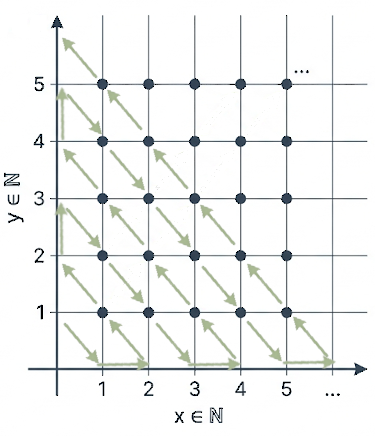

> **Descripción del método:** En el plano cartesiano $\mathbb{N}^2$, se trazan flechas diagonales que conectan los puntos. La primera diagonal une $(1,1)$, la segunda $(1,2)$ con $(2,1)$, la tercera $(1,3)\to(2,2)\to(3,1)$, y así sucesivamente en forma de zigzag. Visualmente es el único método que permite seguir un camino continuo que abarca exhaustivamente todo $\mathbb{N}^2$.

Este recorrido diagonal se expresa con la siguiente función biyectiva $f(n,m)$:
$$f(n,m) = \frac{(n+m)(n+m+1)}{2} + m$$
* $\frac{(n+m)(n+m+1)}{2}$: Representa el área del triángulo formado (número de puntos hasta la diagonal actual) *i.e.* $\frac{B\cdot A}{2}$.
* $+ m$: Representa el avance o la coordenada específica dentro de esa misma diagonal.

**Ejemplo:** ¿Qué posición ocupa el punto $(1,1)$?
$$f(1,1) = \frac{(1+1)(1+1+1)}{2} + 1 = \frac{2 \cdot 3}{2} + 1 = \frac{6}{2} + 1 = 4$$
Es decir el punto $(1,1)$ está en la diagonal $2$ la cual tiene $3$ puntos. Entonces, el recorrido de la diagonal, hasta el punto $(1,1)$ se han recorrido exactamente $4$ puntos de forma ordenada.

Es evidente entonces que $f(n,m)$ conforma una biyección perfecta $f: \mathbb{N}^2 \to \mathbb{N}$.

**Conclusión:** El producto cartesiano de conjuntos infinitos numerables es, a su vez, infinito numerable.
$$\mathbb{N}^2 \equiv \mathbb{N} \implies \text{Card}(\mathbb{N}^2) = \text{Card}(f(\mathbb{N} \times \mathbb{N})) = \text{Card}(\mathbb{N}) = \aleph_0$$
Recorrer el plano $\mathbb{N}^2$ en una línea continua (diagonal) demuestra que tiene "la misma cantidad" de puntos que la recta infinita unidimensional $\mathbb{N}$.

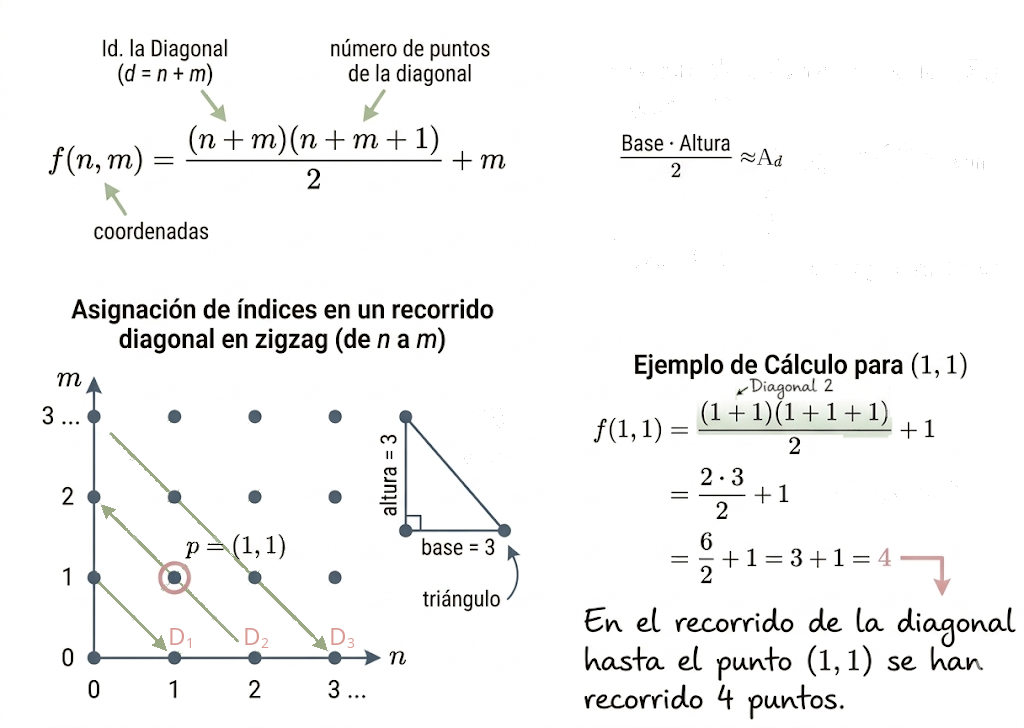

# Unión de Conjuntos Infinitos Numerables

Aplicando nuestra lógica hasta ahora (y la analogía de Hilbert), analizamos qué ocurre con la unión ($\cup$) de conjuntos:

1.  **La unión de dos conjuntos infinitos numerables** ($A \equiv B \equiv \mathbb{N}$) es también infinito numerable: $A \cup B \equiv \mathbb{N}$.
    > *Hotel de Hilbert (Caso 1):* Si tenemos un número infinito de nuevos huéspedes, le pedimos a los huéspedes actuales que se muden a la habitación **par** correspondiente a su número ($n \to 2n$). Esto dejará libres todas las infinitas habitaciones **impares** para acomodar al nuevo número infinito de huéspedes sin problemas.
2.  **La unión de un conjunto finito y uno infinito numerable** ($B \equiv [1,n]$ y $A \equiv \mathbb{N}$) es infinito numerable: $A \cup B \equiv \mathbb{N}$.
    > *Hotel de Hilbert (Caso 2):* Movemos a todos los huéspedes actuales $n$ habitaciones a la derecha. Esto libera exactamente $n$ habitaciones al inicio para el nuevo grupo finito.
3.  **La unión infinita numerable de conjuntos infinitos numerables** es infinita numerable.
Sea $A_n \equiv \mathbb{N}$:
$$\left( \bigcup_{n \in \mathbb{N}} A_n \right) \equiv \mathbb{N} \implies \text{Card}\left(\bigcup_{n \in \mathbb{N}} A_n\right) = \aleph_0$$
    > *Hotel de Hilbert (Caso 3):* Imagina que llegan infinitos autobuses, y cada autobús trae infinitos pasajeros. Incluso en este caso extremo, todos caben en el hotel aplicando el **Método Diagonal de Cantor**. Cada autobús $A_n$ representa una columna en el plano $\mathbb{N}^2$, y los pasajeros son las filas. Como ya demostramos que $\mathbb{N}^2 \equiv \mathbb{N}$, entonces la unión infinita $\bigcup A_n \equiv \mathbb{N}$.

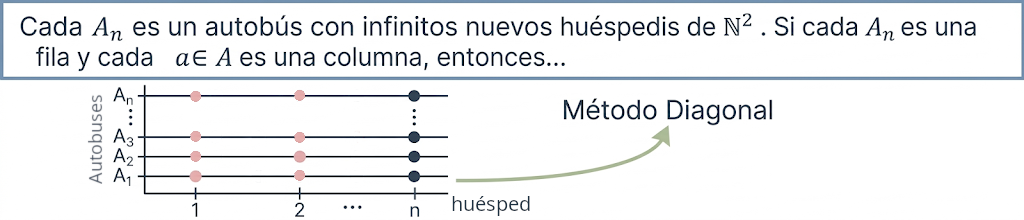

## Consecuencias y Extensiones

### $\mathbb{Z}$ y $\mathbb{Q}$ son Infinitos Numerables

¿Por qué los conjuntos de los números Enteros y Racionales tienen el mismo tamaño que los Naturales?

* **Los Enteros ($\mathbb{Z} \equiv \mathbb{N}$):**
Es evidente que los enteros positivos $\mathbb{Z}_+ \equiv \mathbb{N}$ (son isomorfos y existe biyectividad). Por la misma lógica de simetría, los enteros negativos $\mathbb{Z}_- \equiv \mathbb{N}$. Como la unión de dos conjuntos infinitos numerables es infinito numerable, entonces $\mathbb{Z}_+ \cup \mathbb{Z}_- = \mathbb{Z} \equiv \mathbb{N}$.
* **Los Racionales ($\mathbb{Q} \equiv \mathbb{N}$):**
Los elementos de los racionales positivos $\mathbb{Q}_+$ tienen la forma fraccionaria $\frac{p}{q}$, donde $p, q \in \mathbb{N}$. Si mapeamos $p$ como las filas y $q$ como las columnas de un plano cartesiano, vemos que existe una aplicación $f: \mathbb{Q}_+ \to \mathbb{N}^2$ (por el método diagonal de Cantor).

Por tanto, $\mathbb{Q}_+ \equiv \mathbb{N}^2 \equiv \mathbb{N}$.
Aplicando la misma lógica a los negativos ($\mathbb{Q}_-$) y uniendo ambos, $\mathbb{Q}_+ \cup \mathbb{Q}_- \equiv \mathbb{N}$.

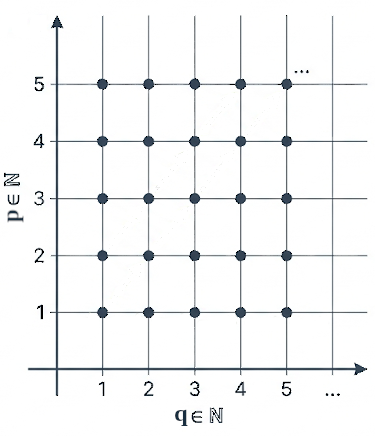

### Conjunto de Partes de $n$ elementos: $\mathcal{P}_n(\mathbb{N})$

El conjunto $\mathcal{P}_n(\mathbb{N})$ se define como el conjunto de todos los posibles subconjuntos finitos de $\mathbb{N}$ que tienen un tamaño específico $n$:
$$\mathcal{P}_n(\mathbb{N}) = \{ A \subset \mathbb{N} \mid \text{Card}(A) = n \}$$
> Ejemplo: $\mathcal{P}_5(\mathbb{N})=\{\text{todos los subconjuntos de } \mathbb{N} \text{ de tamaño 5}\}$.

Resulta que $\mathcal{P}_n(\mathbb{N}) \equiv \mathbb{N}$ es **infinito numerable**, lo cual se demuestra iterando el método diagonal de Cantor:
* $\mathcal{P}_2(\mathbb{N}) = \{ \text{todas las parejas posibles} \} \implies \mathcal{P}_2(\mathbb{N}) \equiv \mathbb{N}^2 \equiv \mathbb{N}$. Es evidente que $\mathcal{P}_2(\mathbb{N})$ es el plano cartesiano en si mismo $\mathbb{N}^2$.  
Pero lo mismo ocurre con $\mathcal{P}_3, \mathcal{P}_4, \cdots, \mathcal{P}_n$
* $\mathcal{P}_3(\mathbb{N})$ forma un espacio tridimensional (un "cubo" $\mathbb{N}^3$), pero este cubo puede aplanarse en un plano proyectando los ejes *i.e.* eje $x=x$ y eje $y= (y,z)$ siendo $(x,y,z) \in \mathbb{N}^3$,  y por tanto, usando el método de Cantor, también es infinito numerable $\mathcal{P}_3(\mathbb{N}) \equiv \mathbb{N}$. Esto escala inductivamente a cualquier dimensión $n$.

Por lo que, al final, $\mathcal{P}_n(\mathbb{N}) \equiv \mathbb{N}$ y, por tanto, $\text{card} \left( \mathcal{P}_n(\mathbb{N}) \right) = \aleph_0$

### El Conjunto de Partes Finitas: $\mathcal{P}_F(\mathbb{N})$

Definimos $\mathcal{P}_F(\mathbb{N})$ como la unión de todos los conjuntos de partes de $n$ elementos:
$$\mathcal{P}_F(\mathbb{N}) = \{ \mathcal{P}_1(\mathbb{N}), \mathcal{P}_2(\mathbb{N}), \mathcal{P}_3(\mathbb{N}), \dots, \mathcal{P}_n(\mathbb{N}), \dots \}$$
$$\mathcal{P}_F(\mathbb{N}) = \bigcup_{n \in \mathbb{N}} \mathcal{P}_n(\mathbb{N})$$

**¿Por qué $\mathcal{P}_F(\mathbb{N}) \equiv \mathbb{N}$ es infinito numerable?**
Porque, como se demostró en el Caso 3 del Hotel de Hilbert: *"La unión infinita numerable de conjuntos infinitos numerables es, invariablemente, infinita numerable"*.